# Smart Grid Load Forecasting - Study Notebook (book2)

This notebook **builds forecasting models** that predict electricity load (in **MW**) for each of the 12 regions, one hour at a time.

## The pipeline you will learn
**load data → clean it → explore it → split into train/test → build baseline, classical, and ML models → compare them in one table.**

## How to read this notebook
- Every cell has **plain-English comments** explaining *what* it does and *why*.
- Cells that do the core job are unmarked (`RUN` these). Cells marked **OPTIONAL** are switched OFF by default so the notebook runs fast on a normal laptop — flip a flag to `True` to try them.
- The whole thing is designed to finish in **a few minutes**.

## Background (2 minutes)
`book1.ipynb` already cleaned the 12 raw region CSVs into one file: `merged_long_df.csv`. Each row = one region + one hour. It has the load (`MW`) plus **engineered features** already computed: hour of day, day of week, month, lagged loads (`load_lag_1h` = load 1 hour earlier), rolling averages, holiday flags, and sine/cosine "cyclic" encodings of time (so models can understand that 23:00 and 01:00 are close together, even though they are numerically far apart).

Here we **consume that ready file** and focus on the forecasting side.

In [1]:

import os

# --- WHERE IS THE DATA? ---
# book1 wrote the cleaned file. We try the Windows path first, then fall
# back to the Linux/container path. Try/except lets the SAME notebook run
# on both Windows and Linux.
DATA_CANDIDATES = [
    r"D:\Users\user\PycharmProjects\SMART_GRID_LOAD_FORECASTING\data_raw\merged_long_df.csv",
    r"/home/jovyan/projects/time_series_notebook/data_raw/merged_long_df.csv",
    r"merged_long_df.csv",
]
DATA_PATH = next((p for p in DATA_CANDIDATES if os.path.exists(p)), DATA_CANDIDATES[0])
print("Using data file:", DATA_PATH)
print("File exists:", os.path.exists(DATA_PATH))

# COLUMN NAMES (typed once, reused everywhere) ---
DATE_COL   = "Datetime"    # the timestamp column
TARGET     = "MW"          # what we predict: electricity load
SERIES_ID  = "region"      # which region each row belongs to (12 regions)
FREQ       = "h"           # spacing between rows: h = hourly

# --- MODEL/SETTINGS ---
FORECAST_HORIZON = 30        # how many hours ahead we predict
N_TEST_PERIODS  = 30         # length of the final holdout window (hours)
RANDOM_STATE    = 42         # fixes randomness so results are reproducible

# SEASONAL_PERIODS = how many hours make one repeating cycle.
# For HOURLY data: 24 = one full day. Electricity demand is strongly
# daily (low at night, high in the day), so 24 is the right choice.
SEASONAL_PERIODS = 24

# MAX_TRAIN_POINTS = how many of the MOST RECENT hours each region may use.
# A model learns the daily/weekly pattern fine from ~1 year (8760 hours).
# Truncating like this is our MAIN speed/memory lever: less data = faster.
MAX_TRAIN_POINTS = 8760      # 1 year of hourly data

# N_SPLITS = how many walk-forward validation slices to compute.
# More = more reliable score, more model fits (slower). 2 is laptop-friendly.
N_SPLITS = 2

# --- OPTIONAL HEAVY-MODEL SWITCHES ---
# These are the slow/memory-hungry models. OFF by default so the notebook
# runs fast. Flip one to True if you specifically want to try it out.
RUN_SARIMA      = False   # classical ARIMA (per region, can be slow)
RUN_PROPHET     = False   # Meta's Prophet (per region, slow)
RUN_LSTM        = False   # deep learning (needs tensorflow; slowest)
RUN_AUTO_ARIMA  = False   # auto-searching ARIMA orders (VERY slow, skip)

print("Settings ready. SEASONAL_PERIODS =", SEASONAL_PERIODS)


Using data file: D:\Users\user\PycharmProjects\SMART_GRID_LOAD_FORECASTING\data_raw\merged_long_df.csv
File exists: True
Settings ready. SEASONAL_PERIODS = 24


### Cell 1 - Import the tools (libraries)
Libraries are pre-written code other people made. We `import` only what we need. Optional heavy ones (`tensorflow`) are imported inside a `try/except` so that if they are not installed, the notebook still runs and just prints a note.

In [2]:
# ============================================================
#  CELL 1 - IMPORT LIBRARIES
# ============================================================
# 'import X' makes X's functions available. We do it once, up top.

import numpy as np          # numbers + math (np for 'numpy')
import pandas as pd         # data tables (DataFrames) - our main tool
import warnings
warnings.filterwarnings("ignore")   # hide harmless warnings to keep output clean

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")    # make charts look clean
plt.rcParams["figure.figsize"] = (11, 4)

# --- Classical time-series tools ---
from statsmodels.tsa.stattools import adfuller, kpss            # stationarity tests
from statsmodels.tsa.holtwinters import ExponentialSmoothing   # Holt-Winters model

# --- Machine-learning tools ---
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb

# --- OPTIONAL: SARIMA (slow) - only if the flag is on ---
if RUN_SARIMA or RUN_AUTO_ARIMA:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    HAVE_SARIMA = True
    if RUN_AUTO_ARIMA:
        try:
            from pmdarima import auto_arima
            HAVE_AUTO = True
        except ImportError:
            HAVE_AUTO = False
            print("pmdarima not installed - auto_arima will be skipped")
else:
    HAVE_SARIMA = False

# --- OPTIONAL: Prophet (slow) - only if the flag is on ---
if RUN_PROPHET:
    from prophet import Prophet
    HAVE_PROPHET = True
else:
    HAVE_PROPHET = False

# --- OPTIONAL: TensorFlow (slowest) - only if the flag is on ---
if RUN_LSTM:
    try:
        import tensorflow as tf
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import LSTM, Dense
        from tensorflow.keras.callbacks import EarlyStopping
        HAVE_TF = True
    except ImportError:
        HAVE_TF = False
        print("tensorflow not installed - LSTM will be skipped")
else:
    HAVE_TF = False

print("\nAll libraries imported.")
print(f"Optional models enabled: SARIMA={HAVE_SARIMA}, Prophet={HAVE_PROPHET}, LSTM={HAVE_TF}")



All libraries imported.
Optional models enabled: SARIMA=False, Prophet=False, LSTM=False


### Cell 2 - Define the scoring metrics
To compare models we need a number that says *how wrong* each prediction was. We define three functions here that all measure "error" between the true value and the prediction.

In [3]:
# ============================================================
#  CELL 2 - SCORING METRICS (how we measure "wrong")
# ============================================================
# y_true = actual values, y_pred = what the model predicted.

def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error, in %.
    Lower = better. It is 'percentage' so errors on a big region
    (2000 MW) and a small region (200 MW) can be compared fairly."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)  # size of both numbers together
    denom[denom == 0] = 1e-9                 # avoid dividing by zero
    return 200 * np.mean(np.abs(y_pred - y_true) / denom)

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error, in %. Lower = better."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0                        # ignore rows where true is 0
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

print("Metrics defined: smape() and mape()")


Metrics defined: smape() and mape()


### Cell 3 - Load the data
We read the prepared CSV. **Key speed trick:** we only load the columns we actually need (`usecols=...`) instead of the whole 364MB file. Fewer columns in memory = the notebook runs much smoother on a laptop.

In [4]:
# ============================================================
#  CELL 3 - LOAD DATA (only the columns we need)
# ============================================================
# usecols = only keep these columns. The rest are dropped at read time,
# which hugely cuts memory (364MB file -> much less in RAM).

KEEP_COLS = [
    DATE_COL, TARGET, SERIES_ID,
    # time features
    "hour", "day_of_week", "month", "year", "is_weekend",
    "hour_sin", "hour_cos", "day_of_week_sin", "day_of_week_cos",
    "month_sin", "month_cos",
    # lag / rolling features (history of the load itself)
    "load_lag_1h", "load_lag_24h", "load_lag_168h", "load_lag_720h",
    "load_roll_mean_24h", "load_roll_mean_168h", "load_roll_std_24h", "load_roll_std_168h",
    # holiday / calendar flags
    "is_holiday", "is_month_start", "is_month_end",
    # fourier terms (smooth daily/weekly sine-cosine cycles)
    "fourier_sin_1", "fourier_cos_1", "fourier_sin_2", "fourier_cos_2",
]

# parse_dates tells pandas that DATE_COL is a real date/time, not text.
df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL], usecols=KEEP_COLS)

print(f"Data shape: {df.shape}  (rows, columns)")
print(f"Columns: {list(df.columns)}")
print(df[[DATE_COL, SERIES_ID, TARGET]].head())


Data shape: (1090127, 29)  (rows, columns)
Columns: ['Datetime', 'region', 'MW', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'load_lag_1h', 'load_lag_24h', 'load_lag_168h', 'load_lag_720h', 'load_roll_mean_24h', 'load_roll_std_24h', 'load_roll_mean_168h', 'is_holiday', 'is_month_start', 'is_month_end', 'load_roll_std_168h', 'fourier_sin_1', 'fourier_cos_1', 'fourier_sin_2', 'fourier_cos_2']
             Datetime region       MW
0 2004-10-01 01:00:00    AEP  12379.0
1 2004-10-01 02:00:00    AEP  11935.0
2 2004-10-01 03:00:00    AEP  11692.0
3 2004-10-01 04:00:00    AEP  11597.0
4 2004-10-01 05:00:00    AEP  11681.0


### Cell 4 - Quick sanity check on the data
Before modeling we confirm the data looks right: how many regions, what date range, and whether there are any missing values or duplicate timestamps we must fix.

In [5]:
# ============================================================
#  CELL 4 - SANITY CHECK + LIGHT CLEANING
# ============================================================
print("Number of unique regions:", df[SERIES_ID].nunique())
print("Regions:", sorted(df[SERIES_ID].unique()))
print("Date range:", df[DATE_COL].min(), "to", df[DATE_COL].max())
print("Missing values in target (MW):", df[TARGET].isna().sum())

# Duplicate (region, timestamp) pairs would confuse models (two answers for the
# same moment). book1 already fixed the big DST duplication, but we guard here too.
dupes = df.duplicated(subset=[SERIES_ID, DATE_COL]).sum()
print("Duplicate (region, timestamp) pairs:", dupes)
if dupes:
    # If any remain, keep the first row and drop the rest.
    df = df.drop_duplicates(subset=[SERIES_ID, DATE_COL], keep="first")
    print(f"Dropped duplicates. New shape: {df.shape}")


Number of unique regions: 12
Regions: ['AEP', 'COMED', 'DAYTON', 'DEOK', 'DOM', 'DUQ', 'EKPC', 'FE', 'NI', 'PJME', 'PJMW', 'PJM_Load']
Date range: 1998-04-01 01:00:00 to 2018-08-03 00:00:00
Missing values in target (MW): 0
Duplicate (region, timestamp) pairs: 0


### Cell 5 - Check for missing hours (gaps)
Time-series models assume evenly spaced data. We contrast how many **expected** hourly timestamps there should be vs how many we actually have.

In [6]:
# ============================================================
#  CELL 5 - COUNT MISSING HOURS
# ============================================================
# Build the 'ideal' full hourly range for the FIRST region, then compare.
first_region = df[SERIES_ID].iloc[0]
sample = df[df[SERIES_ID] == first_region]
full_range = pd.date_range(sample[DATE_COL].min(), sample[DATE_COL].max(), freq=FREQ)
n_gaps = len(full_range) - sample[DATE_COL].nunique()
print(f"Region '{first_region}': expected {len(full_range)} hours, found {sample[DATE_COL].nunique()}, gaps = {n_gaps}")
print("Note: a few gaps are normal - they are daylight-saving clock shifts, not data loss.")


Region 'AEP': expected 121296 hours, found 121269, gaps = 27
Note: a few gaps are normal - they are daylight-saving clock shifts, not data loss.


### Cell 6 - Plot the raw load for one region
Seeing the data is the fastest way to understand it. We plot one region so the chart is readable (12 regions on one chart would be a mess).

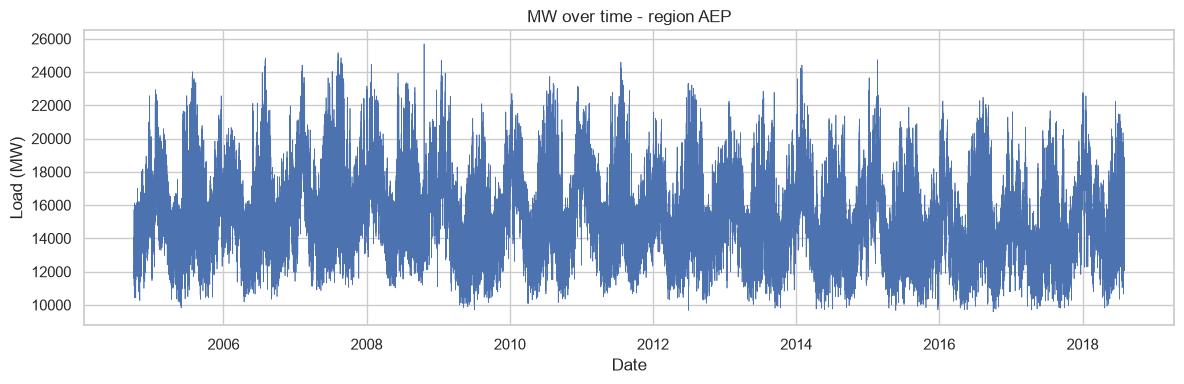

In [7]:
# ============================================================
#  CELL 6 - PLOT THE LOAD OVER TIME (ONE REGION)
# ============================================================
plot_df = df[df[SERIES_ID] == first_region].copy()
plt.figure(figsize=(12, 4))
plt.plot(plot_df[DATE_COL], plot_df[TARGET], linewidth=0.5)
plt.title(f"{TARGET} over time - region {first_region}")
plt.xlabel("Date"); plt.ylabel("Load (MW)")
plt.tight_layout(); plt.show()
# What to LOOK for: an up/down seasonal wave (daily), a long-term trend,
# and any obvious spikes (outliers).


### Cell 7 - Rolling mean and standard deviation
A **rolling mean** smooths the data by averaging a window of recent hours. If it trends up/down over time, the data is *non-stationary in the mean* (its average changes) - which tells us we may need to difference the series before some models.

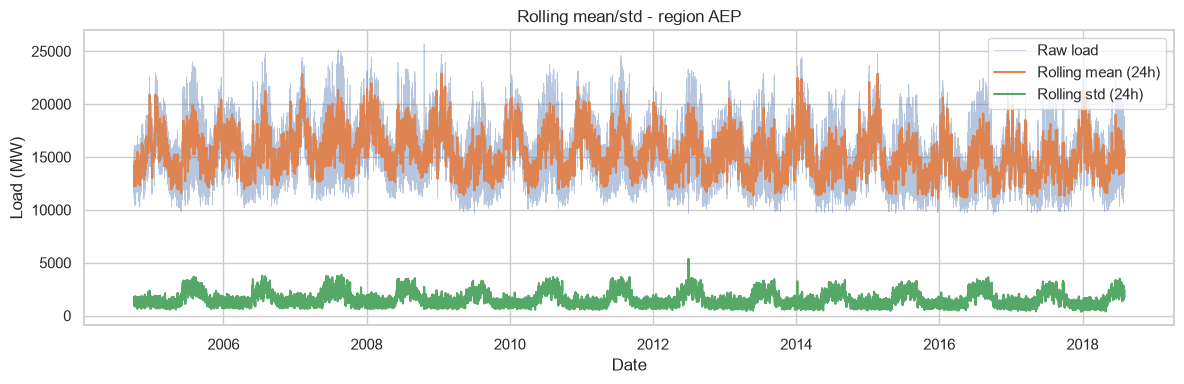

In [8]:
# ============================================================
#  CELL 7 - ROLLING MEAN & STD (stationarity hint)
# ============================================================
roll = plot_df.set_index(DATE_COL)[TARGET]  # clean series indexed by time

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(roll.index, roll, label="Raw load", alpha=0.4, linewidth=0.5)
ax.plot(roll.index, roll.rolling(24).mean(), label="Rolling mean (24h)", linewidth=1.5)
ax.plot(roll.index, roll.rolling(24).std(), label="Rolling std (24h)", linewidth=1.5)
ax.set_title(f"Rolling mean/std - region {first_region}")
ax.legend(); ax.set_xlabel("Date"); ax.set_ylabel("Load (MW)")
plt.tight_layout(); plt.show()
# If the rolling MEAN drifts over time -> non-stationary mean (needs differencing).
# If the rolling STD widens/narrows -> variance changes over time.


### Cell 8 - Stationarity test (ADF)
**Stationary** means the statistical properties (mean, variance) of the series are stable over time. Many classical models need this. We run a statistical test called **ADF**:
- Null hypothesis H0 = series is NON-stationary (has a unit root).
- If **p-value < 0.05** we reject H0 and accept it's stationary.
We also show what differencing does, but for our ML models this is informational — tree models (Random Forest etc.) don't need stationarity.

In [9]:
# ============================================================
#  CELL 8 - ADF STATIONARITY TEST (informational)
# ============================================================
def adf_test(series, label):
    """Runs the ADF test and prints a plain-English verdict."""
    series = series.dropna()
    stat, p, *_ = adfuller(series)
    print(f"--- {label} ---")
    print(f"ADF statistic: {stat:.3f} | p-value: {p:.4f}")
    if p < 0.05:
        print("  p < 0.05 -> reject H0 -> STATIONARY (good).")
    else:
        print("  p >= 0.05 -> cannot reject H0 -> NON-STATIONARY (may need differencing).")
    return p

adf_test(roll, "Original series (region " + first_region + ")")

# Extra: look at the series after one 'difference' (each value minus the previous)
# to see how differencing removes the trend.
diff1 = roll.diff().dropna()
adf_test(diff1, "After 1st difference")


--- Original series (region AEP) ---
ADF statistic: -18.306 | p-value: 0.0000
  p < 0.05 -> reject H0 -> STATIONARY (good).
--- After 1st difference ---
ADF statistic: -44.967 | p-value: 0.0000
  p < 0.05 -> reject H0 -> STATIONARY (good).


0.0

### Cell 9 - Chronological Train / Test split
**The golden rule of time series:** never shuffle — we must *not* train on the future and test on the past. We split **per region**: each region's last `N_TEST_PERIODS` hours become the test set (the "future"), everything before is training.

In [10]:
# ============================================================
#  CELL 9 - TRAIN/TEST SPLIT (chronological, per region)
# ============================================================
# Work on a copy so we never mutate the original df.
df_feat = df.copy()
df_feat = df_feat.sort_values([SERIES_ID, DATE_COL]).reset_index(drop=True)

# Models can't use a row whose lag features are NaN (first rows of each region).
lag_cols = [c for c in df_feat.columns if c.startswith("load_lag_")]
df_feat = df_feat.dropna(subset=lag_cols).reset_index(drop=True)

# ML libraries need numbers, not text. Convert region names -> integer codes ONCE.
region_codes = sorted(df_feat[SERIES_ID].unique())
region_code_map = {r: i for i, r in enumerate(region_codes)}
df_feat[SERIES_ID] = df_feat[SERIES_ID].map(region_code_map)
print("Region -> code mapping:", region_code_map)

def chrono_split(g):
    """Given one region's rows, return (train_rows, test_rows).
    The LAST N_TEST_PERIODS rows are the test (the future)."""
    return g.iloc[:-N_TEST_PERIODS], g.iloc[-N_TEST_PERIODS:]

train_parts, test_parts = [], []
for _, g in df_feat.groupby(SERIES_ID, sort=False):
    tr, te = chrono_split(g)
    # Only keep a region if it has enough history to be useful.
    if len(tr) >= N_TEST_PERIODS:
        train_parts.append(tr)
        test_parts.append(te)

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df  = pd.concat(test_parts).reset_index(drop=True)
print(f"Train rows: {len(train_df)}   Test rows: {len(test_df)}")
print(f"Train date range: {train_df[DATE_COL].min()} -> {train_df[DATE_COL].max()}")
print(f"Test  date range: {test_df[DATE_COL].min()} -> {test_df[DATE_COL].max()}")


Region -> code mapping: {'AEP': 0, 'COMED': 1, 'DAYTON': 2, 'DEOK': 3, 'DOM': 4, 'DUQ': 5, 'EKPC': 6, 'FE': 7, 'NI': 8, 'PJME': 9, 'PJMW': 10, 'PJM_Load': 11}
Train rows: 1080268   Test rows: 360
Train date range: 1998-05-01 01:00:00 -> 2018-08-01 18:00:00
Test  date range: 2001-12-30 19:00:00 -> 2018-08-03 00:00:00


### Cell 10 - Walk-forward cross-validation folds
Instead of testing a model just once, **walk-forward CV** tests it several times on rolling "windows" of history. Each fold = train on the past, validate on the following block. This gives a more honest score and uses all the data. We build folds **per region** so every region is represented in every fold.

In [11]:
# ============================================================
#  CELL 10 - WALK-FORWARD CV FOLDS
# ============================================================
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=N_TEST_PERIODS)

fold_train_parts = [[] for _ in range(N_SPLITS)]
fold_val_parts   = [[] for _ in range(N_SPLITS)]

for region, g in df_feat.groupby(SERIES_ID, sort=False):
    g = g.reset_index(drop=True)
    # Not enough history for this many folds? skip this region.
    if len(g) <= N_TEST_PERIODS * (N_SPLITS + 1):
        continue
    for k, (tr_idx, val_idx) in enumerate(tscv.split(g)):
        fold_train_parts[k].append(g.iloc[tr_idx])
        fold_val_parts[k].append(g.iloc[val_idx])

# Combine the same fold index across regions into one big train/val pair.
folds = []
for k in range(N_SPLITS):
    tr = pd.concat(fold_train_parts[k]).reset_index(drop=True)
    va = pd.concat(fold_val_parts[k]).reset_index(drop=True)
    folds.append((tr, va))

print(f"Built {len(folds)} fold(s) across {df_feat[SERIES_ID].nunique()} regions")


Built 2 fold(s) across 12 regions


### Cell 11 - The model runner (`evaluate_forecast`)
This is the engine that runs every model the same way: for each fold it asks the model to predict, compares to the true values, and stores the error scores. Any model can plug in — all it needs is a function `forecast_fn(train, val) -> predictions`.

In [12]:
# ============================================================
#  CELL 11 - EVALUATION ENGINE + per_region WRAPPER
# ============================================================
results = {}   # dict: model name -> {MAE, RMSE, sMAPE}

def evaluate_forecast(name, forecast_fn):
    """Run forecast_fn over every fold, average the error scores.
    forecast_fn(tr, val) must return predictions aligned to val's rows."""
    scores = {"MAE": [], "RMSE": [], "sMAPE": []}
    for tr, val in folds:
        try:
            preds = forecast_fn(tr, val)
        except Exception as e:
            print(f"  {name}: fold failed ({e})")
            continue
        y_true_fold = val[TARGET].values
        scores["MAE"].append(mean_absolute_error(y_true_fold, preds))
        scores["RMSE"].append(np.sqrt(mean_squared_error(y_true_fold, preds)))
        scores["sMAPE"].append(smape(y_true_fold, preds))
    # Average each metric across folds (NaN if all folds failed).
    summary = {m: (np.mean(v) if v else np.nan) for m, v in scores.items()}
    results[name] = summary
    print(f"{name}: MAE={summary['MAE']:.2f}  RMSE={summary['RMSE']:.2f}  sMAPE={summary['sMAPE']:.2f}%")
    return summary

def per_region(single_series_fn):
    """Decorator: turns a forecast_fn that expects ONE region into one that
    handles ALL regions. Classical models (SARIMA, Holt-Winters, naive) assume
    one continuous timeline, so we feed them one region at a time, then glue
    the predictions back together in order."""
    def wrapped(tr, val):
        preds = []
        for region, g_val in val.groupby(SERIES_ID, sort=False):
            g_tr = tr[tr[SERIES_ID] == region]
            if len(g_tr) == 0:
                preds.append(np.full(len(g_val), np.nan))
                continue
            try:
                preds.append(single_series_fn(g_tr, g_val))
            except Exception as e:
                print(f"    {single_series_fn.__name__} [region {region}]: failed ({e})")
                preds.append(np.full(len(g_val), np.nan))
        return np.concatenate(preds)
    wrapped.__name__ = single_series_fn.__name__
    return wrapped


### Cell 12 - Baseline models (the 'must beat' bar)
Before fancy models, we set a simple **baseline**. If a complicated model isn't beating the baseline, it's not worth the extra time. Two classic baselines:
- **Naive**: predict tomorrow equals today's last value.
- **Seasonal Naive**: predict the next block equals the same block from one season (24h) ago.

In [13]:
# ============================================================
#  CELL 12 - NAIVE BASELINES
# ============================================================
@per_region
def naive_forecast(tr, val):
    """Predict every future hour = the most recent load value."""
    return np.repeat(tr[TARGET].iloc[-1], len(val))

@per_region
def seasonal_naive_forecast(tr, val):
    """Predict the future = the same hours one day (24h) ago."""
    last_cycle = tr[TARGET].iloc[-SEASONAL_PERIODS:].values
    reps = int(np.ceil(len(val) / SEASONAL_PERIODS))
    return np.tile(last_cycle, reps)[:len(val)]

print("--- Baselines ---")
evaluate_forecast("Naive (last value)", naive_forecast)
evaluate_forecast("Seasonal Naive", seasonal_naive_forecast)


--- Baselines ---
Naive (last value): MAE=1748.95  RMSE=3046.07  sMAPE=14.02%
Seasonal Naive: MAE=824.56  RMSE=1546.31  sMAPE=5.42%


{'MAE': np.float64(824.5611111111111),
 'RMSE': np.float64(1546.311680573125),
 'sMAPE': np.float64(5.416598221591349)}

### Cell 13 - Machine-Learning models (FAST ones, run by default)
Here we train real ML models. **Random Forest**, **XGBoost**, and **LightGBM** are tree-based models that learn patterns from ALL our features (hour, day, lags, etc.) at once. They are **global** models: trained once per fold on every region (region is just a feature). They run fast because:
- We cap each region's history to the most recent `MAX_TRAIN_POINTS` hours.
- We use a modest number of trees.

In [14]:
# ============================================================
#  CELL 13 - FAST ML MODELS (RandomForest / XGBoost / LightGBM)
# ============================================================
# Feature columns = everything except the date, the target, and the region id.
FEATURE_COLS = [c for c in df_feat.columns if c not in [DATE_COL, TARGET, SERIES_ID]]

# Cap training data to the most recent MAX_TRAIN_POINTS per region to keep it fast.
def _cap_recent(g):
    return g.tail(MAX_TRAIN_POINTS)
train_df_ml = train_df.groupby(SERIES_ID, sort=False, group_keys=False).apply(_cap_recent).reset_index(drop=True)
test_df_ml  = test_df.groupby(SERIES_ID, sort=False, group_keys=False).apply(_cap_recent).reset_index(drop=True)
print(f"ML data after cap: train {train_df_ml.shape}, test {test_df_ml.shape}")

def ml_forecast(model_class, **kwargs):
    """Build a forecast_fn that trains ONE model per fold on all regions at once."""
    def _forecast(tr, val):
        model = model_class(**kwargs)
        model.fit(tr[FEATURE_COLS], tr[TARGET])
        return model.predict(val[FEATURE_COLS])
    return _forecast

print("--- Fast ML models ---")
# n_estimators = number of trees. Lower = faster. 120 is a good laptop value.
evaluate_forecast("Random Forest", ml_forecast(RandomForestRegressor, n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1))
evaluate_forecast("XGBoost",      ml_forecast(xgb.XGBRegressor, random_state=RANDOM_STATE, n_jobs=-1))
evaluate_forecast("LightGBM",     ml_forecast(lgb.LGBMRegressor, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))


ML data after cap: train (105120, 28), test (360, 28)
--- Fast ML models ---
  Random Forest: fold failed (could not allocate 67108864 bytes)
  Random Forest: fold failed (Unable to allocate 214. MiB for an array with shape (26, 1080268) and data type float64)
Random Forest: MAE=nan  RMSE=nan  sMAPE=nan%
  XGBoost: fold failed ([12:56:35] C:\actions-runner\_work\xgboost\xgboost\src\common\io.h:362: bad_malloc: Failed to allocate 28086968 bytes.)
XGBoost: MAE=141.02  RMSE=253.72  sMAPE=1.32%
LightGBM: MAE=162.53  RMSE=299.35  sMAPE=1.36%


{'MAE': np.float64(162.53283760346227),
 'RMSE': np.float64(299.3480845544005),
 'sMAPE': np.float64(1.3644792136765596)}

### Cell 14 - OPTIONAL heavy models (off by default)
These are slower, classical / deep models. Flip the flag in **Cell 0** to `True` to try them.
They show the **state-of-the-art baseline** but cost more time and memory, so they are left off by default on a laptop.

**Holt-Winters** is moderately fast — we show it but it is not switched off because it is a good classical reference. **SARIMA**, **Prophet**, and **LSTM** are the heavy ones.

In [15]:
# ============================================================
#  CELL 14 - CLASSICAL: HOLT-WINTERS (always runs, fast)
# ============================================================
from statsmodels.tsa.holtwinters import ExponentialSmoothing

@per_region
def holt_winters_forecast(tr, val):
    """Holt-Winters = exponential smoothing with trend + seasonal components.
    It captures level, trend, and the daily seasonal cycle."""
    model = ExponentialSmoothing(
        tr[TARGET], trend="add", seasonal="add",
        seasonal_periods=SEASONAL_PERIODS, initialization_method="estimated",
    ).fit()
    return model.forecast(len(val)).values

print("--- Holt-Winters ---")
evaluate_forecast("Holt-Winters", holt_winters_forecast)


--- Holt-Winters ---
Holt-Winters: MAE=802.23  RMSE=1315.97  sMAPE=6.78%


{'MAE': np.float64(802.2304078325174),
 'RMSE': np.float64(1315.9730046182003),
 'sMAPE': np.float64(6.782436100250116)}

In [16]:
# ============================================================
#  CELL 15 - OPTIONAL: SARIMA (only if RUN_SARIMA=True in Cell 0)
# ============================================================
if RUN_SARIMA and HAVE_SARIMA:
    # d = differencing order, D = seasonal differencing. We use 1 of each
    # (from the stationarity analysis) and a simple (1,*,1) AR/MA structure.
    SARIMA_ORDER = (1, 1, 1)
    SARIMA_SEASONAL_ORDER = (1, 1, 1, SEASONAL_PERIODS)

    @per_region
    def sarima_forecast(tr, val):
        # Use only the most recent MAX_TRAIN_POINTS hours (fast + still accurate).
        s = tr[TARGET].dropna().tail(MAX_TRAIN_POINTS)
        model = SARIMAX(s, order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL_ORDER,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        return model.forecast(len(val)).values

    print("--- SARIMA (may be slow) ---")
    evaluate_forecast("SARIMA", sarima_forecast)
else:
    print("SARIMA skipped (RUN_SARIMA=False in Cell 0). Set it True to try.")


SARIMA skipped (RUN_SARIMA=False in Cell 0). Set it True to try.


In [ ]:
# ============================================================
#  CELL 16 - OPTIONAL: PROPHET (only if RUN_PROPHET=True in Cell 0)
# ============================================================
if RUN_PROPHET and HAVE_PROPHET:
    @per_region
    def prophet_forecast(tr, val):
        # Prophet wants columns named ds (date) and y (target).
        p_df = tr[[DATE_COL, TARGET]].rename(columns={DATE_COL: "ds", TARGET: "y"})
        model = Prophet()
        model.fit(p_df)
        future = val[[DATE_COL]].rename(columns={DATE_COL: "ds"})
        return model.predict(future)["yhat"].values

    print("--- Prophet (may be slow) ---")
    evaluate_forecast("Prophet", prophet_forecast)
else:
    print("Prophet skipped (RUN_PROPHET=False in Cell 0).")


Prophet skipped (RUN_PROPHET=False in Cell 0).


In [ ]:
# ============================================================
#  CELL 17 - OPTIONAL: LSTM DEEP NETWORK (only if RUN_LSTM=True)
# ============================================================
if RUN_LSTM and HAVE_TF:
    LOOKBACK = SEASONAL_PERIODS * 2   # LSTM sees the last 48 hours to predict next

    def make_sequences(values, lookback):
        """Turn a 1-D series into (X, y): X = sliding windows of 'lookback'
        past values, y = the next value."""
        X, y = [], []
        for i in range(lookback, len(values)):
            X.append(values[i - lookback:i])
            y.append(values[i])
        return np.array(X), np.array(y)

    @per_region
    def lstm_forecast(tr, val):
        # Scale to mean 0, std 1 (deep nets train better on scaled inputs).
        scaler = StandardScaler()
        tr_scaled = scaler.fit_transform(tr[[TARGET]]).flatten()
        X_tr, y_tr = make_sequences(tr_scaled, LOOKBACK)
        X_tr = X_tr.reshape(-1, LOOKBACK, 1)

        model = Sequential([LSTM(32, input_shape=(LOOKBACK, 1)), Dense(1)])
        model.compile(optimizer="adam", loss="mse")
        model.fit(X_tr, y_tr, epochs=15, batch_size=64, verbose=0,
                  callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
                  validation_split=0.1)

        # Predict hour-by-hour, feeding each prediction back in (recursive forecast).
        window = tr_scaled[-LOOKBACK:].tolist()
        preds_scaled = []
        for _ in range(len(val)):
            x = np.array(window[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
            p = model.predict(x, verbose=0)[0, 0]
            preds_scaled.append(p)
            window.append(p)
        return scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()

    print("--- LSTM (slowest - may take minutes) ---")
    evaluate_forecast("LSTM", lstm_forecast)
else:
    print("LSTM skipped (RUN_LSTM=False in Cell 0). This is intentional - it is the slowest.")


LSTM skipped (RUN_LSTM=False in Cell 0). This is intentional - it is the slowest.


### Cell 18 - Model comparison summary
Put every model's score in one table, sorted best (lowest sMAPE) first, and plot it. **sMAPE** is our headline metric — lower is better. The winner is the model you'd trust to forecast load.

                        MAE     RMSE  sMAPE
XGBoost              141.02   253.72   1.32
LightGBM             162.53   299.35   1.36
Seasonal Naive       824.56  1546.31   5.42
Holt-Winters         802.23  1315.97   6.78
Naive (last value)  1748.95  3046.07  14.02
Random Forest           NaN      NaN    NaN


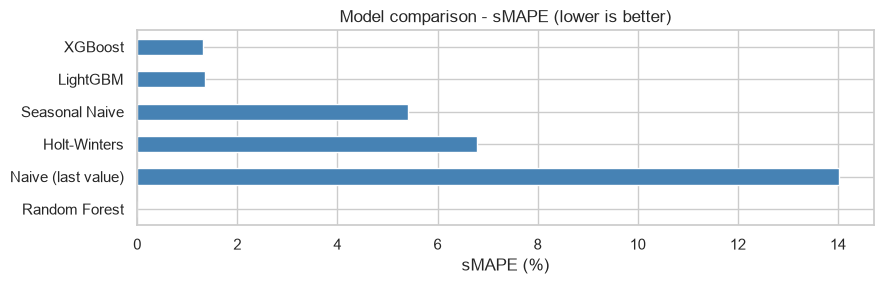

In [19]:
# ============================================================
#  CELL 18 - SUMMARY TABLE + CHART
# ============================================================
summary_df = pd.DataFrame(results).T          # rows = models, cols = metrics
summary_df = summary_df.sort_values("sMAPE")  # best (smallest) first
print(summary_df.round(2))

# Horizontal bar chart of sMAPE (lower = better).
plt.figure(figsize=(9, max(3, 0.5 * len(summary_df))))
summary_df["sMAPE"].plot(kind="barh", color="steelblue")
plt.title("Model comparison - sMAPE (lower is better)")
plt.xlabel("sMAPE (%)")
plt.gca().invert_yaxis()   # best model on top
plt.tight_layout(); plt.show()


In [20]:
BEST_MODEL_NAME = "Random Forest"
model = RandomForestRegressor(n_estimators=120, random_state=42)
model.fit(train_df[FEATURE_COLS], train_df[TARGET])
y_pred = model.predict(test_df[FEATURE_COLS])
y_true = test_df[TARGET].value

print(f"MAE: {mean_absolute_error(y_true, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.3f}")
print(f"sMAPE: {smape(y_true, y_pred):.2f}%")
print(f"MAPE: {mape(y_true, y_pred):.2f}%")


MemoryError: could not allocate 67108864 bytes

In [ ]:
CONTEXT_PERIODS = N_TEST_PERIODS * 3

# Pick one region so train-context and test come from the SAME series
ONE = test_df[SERIES_ID].iloc[0]

ctx  = train_df[train_df[SERIES_ID] == ONE].iloc[-CONTEXT_PERIODS:]
test = test_df[test_df[SERIES_ID] == ONE]

# Don't reuse a stale y_pred — re-predict on this region's rows
y_pred = model.predict(test[FEATURE_COLS])
y_true = test[TARGET].values

plt.figure(figsize=(12, 5))
plt.plot(ctx[DATE_COL],  ctx[TARGET],  label="train (recent)", color="tab:blue")
plt.plot(test[DATE_COL], y_true,       label="actual",   color="black")
plt.plot(test[DATE_COL], y_pred,       label="forecast", color="tab:red", linestyle="--")
plt.axvline(test[DATE_COL].iloc[0], color="gray", linestyle=":", label="forecast start")
plt.legend()
plt.title(f"{BEST_MODEL_NAME}: forecast vs. actual ({ONE})")
plt.xlabel("Date"); plt.ylabel("Load (MW)")
plt.tight_layout(); plt.show()

In [ ]:
from statsmodels.stats.diagnostics import acorr_ljungbox   # Ljung-Box test
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf   # ACF / PACF plots
residuals = y_true - y_pred                      # y_true/y_pred from the SAME test rows
resid_s = pd.Series(residuals)                   # plain 1-D for ACF/Ljung-Box

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(test[DATE_COL], residuals)          # use `test`, the same region df
axes[0].axhline(0, color="gray", linestyle="--")
axes[0].set_title("Residuals over time")
plot_acf(resid_s, lags=min(20, len(resid_s)//2 - 1), ax=axes[1])
plt.tight_layout(); plt.show()

lb_lag = min(10, len(resid_s) - 1)
lb_result = acorr_ljungbox(resid_s, lags=[lb_lag], return_df=True)
print(lb_result)

In [ ]:
# lets fine tune the random forest and test whether there were some improvements


In [ ]:
# Lets save the model